In [4]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder

import matplotlib.pyplot as plt
import seaborn as sns

from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score,confusion_matrix
from sklearn.naive_bayes import GaussianNB

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

In [5]:
data = pd.read_csv('improved_disease_dataset.csv') 
df = pd.DataFrame(data)
print(df.head())

   fever  headache  nausea  vomiting  fatigue  joint_pain  skin_rash  cough  \
0      1         0       1         0        1           0          0      1   
1      0         0       1         0        0           0          1      1   
2      0         0       1         0        1           0          1      1   
3      0         0       1         1        1           0          1      1   
4      1         0       1         0        1           0          0      0   

   weight_loss  yellow_eyes                       disease  
0            1            0  Paralysis (brain hemorrhage)  
1            0            0  Paralysis (brain hemorrhage)  
2            0            0  Paralysis (brain hemorrhage)  
3            1            1  Paralysis (brain hemorrhage)  
4            1            1  Paralysis (brain hemorrhage)  


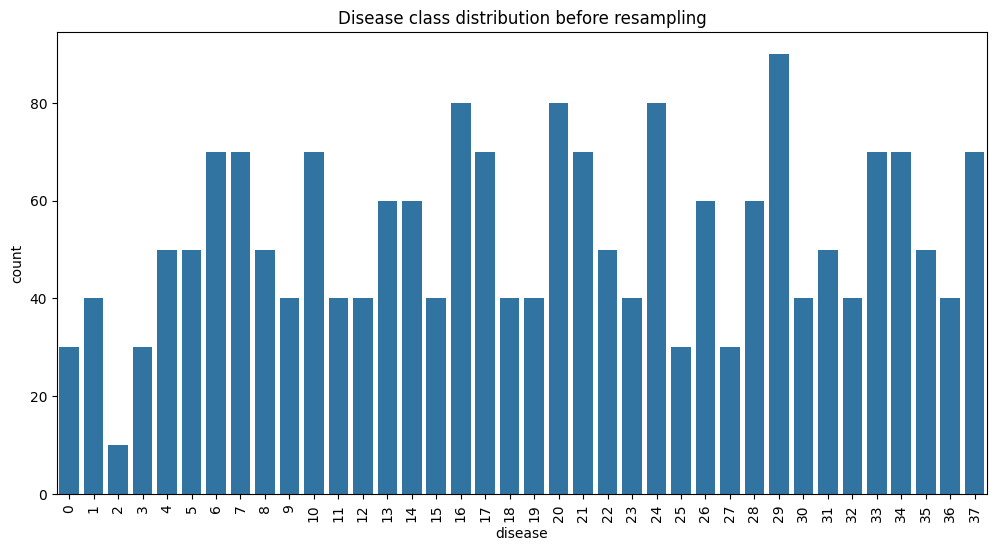

In [6]:
encoder = LabelEncoder()
data['disease'] = encoder.fit_transform(data['disease'])

x = data.iloc[:,:-1]
y = data.iloc[:,-1]

plt.figure(figsize=(12,6))
sns.countplot(x=y)
plt.title("Disease class distribution before resampling")
plt.xticks(rotation=90)
plt.show()

# helpd to fix the imbalace in disease class 
ros =  RandomOverSampler(random_state= 42)
x_resampled,y_resampled = ros.fit_resample(x,y)

In [7]:
if 'gender' in x_resampled.columns:
    le = LabelEncoder()
    x_resampled['gender'] = le.fit_transform(x_resampled['gender'])

# print(x_resampled.head())

x_resampled = x_resampled.fillna(0)

if len(y_resampled.shape) > 1:
    y_resampled = y_resampled.values.ravel()

# print(y_resampled.head())

models = {
    'Decision Tree' : DecisionTreeClassifier(),
    'Random Forest' : RandomForestClassifier(),
    'SVM' : SVC()
}

cv_scoring = "accuracy" 

stratfied_kfold  = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

for model_name,model in models.items():
    try:
        Scores = cross_val_score(
            model,
            x_resampled,
            y_resampled,
            cv = stratfied_kfold,
            n_jobs = -1,
            error_score = "raise"
        )
        print(' = ' * 20)
        print(f"score:{Scores}")
        print(f"model:{model_name}")
        print(f"mean accuracy:{Scores.mean():.4f}")
    except Exception as e:
        print("=" * 20)
        print(f"model:{model_name} failed with an eroor \n")
        print(e)


 =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  = 
score:[0.5497076  0.54385965 0.5380117  0.53654971 0.52631579]
model:Decision Tree
mean accuracy:0.5389
 =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  = 
score:[0.56432749 0.54532164 0.5380117  0.53508772 0.52777778]
model:Random Forest
mean accuracy:0.5421
 =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  =  = 
score:[0.51315789 0.51169591 0.49707602 0.48245614 0.49561404]
model:SVM
mean accuracy:0.5000


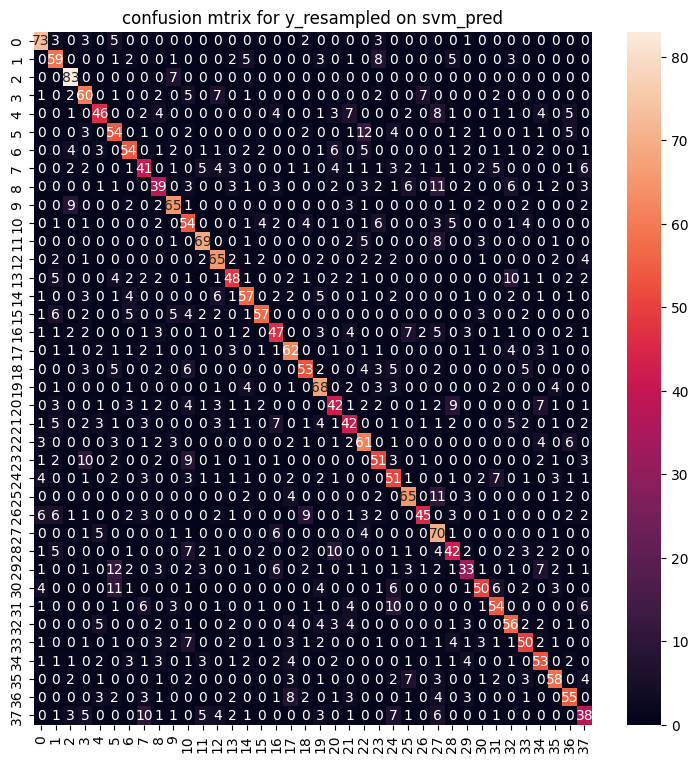

SVM accuracy:0.6052631578947368


In [8]:
#confusion metrix for support vector classifier
svm_model = SVC()
svm_model.fit(x_resampled,y_resampled)
svm_pred = svm_model.predict(x_resampled)

cf_matrix_svm = confusion_matrix(y_resampled,svm_pred)
plt.figure(figsize=(9,9))
plt.title("confusion mtrix for y_resampled on svm_pred")
sns.heatmap(cf_matrix_svm,annot=True,fmt="d" )
plt.show()

print(f"SVM accuracy:{accuracy_score(y_resampled,svm_pred)}")


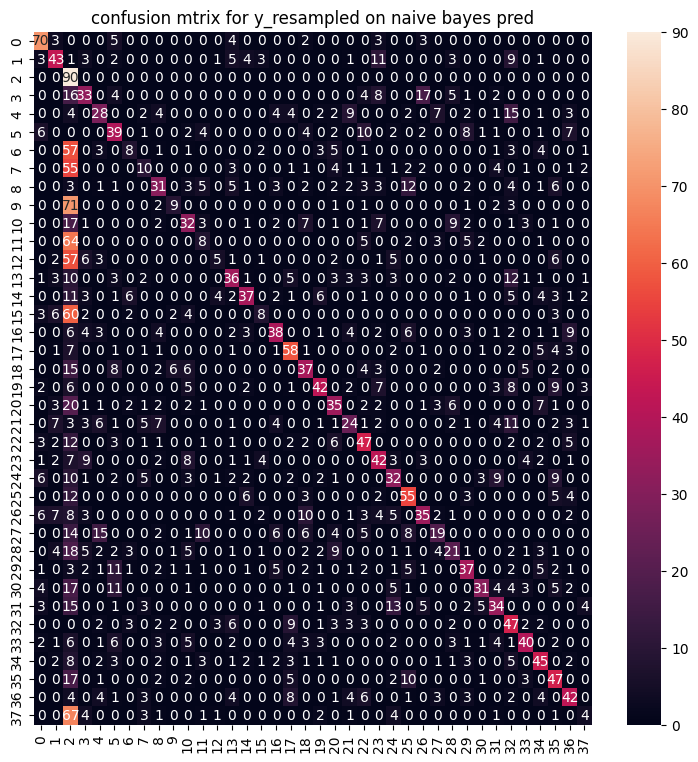

 GaussianNB accuracy:37.98%


In [9]:
#confusion metrix for Gaussian Naive Bayes 
nv_model = GaussianNB()
nv_model.fit(x_resampled,y_resampled)
nv_pred = nv_model.predict(x_resampled)

cf_matrix_nv = confusion_matrix(y_resampled,nv_pred)
plt.figure(figsize=(9,9))
plt.title("confusion mtrix for y_resampled on naive bayes pred")
sns.heatmap(cf_matrix_nv,annot=True,fmt="d" )
plt.show()

print(f" GaussianNB accuracy:{accuracy_score(y_resampled,nv_pred)*100:.2f}%")

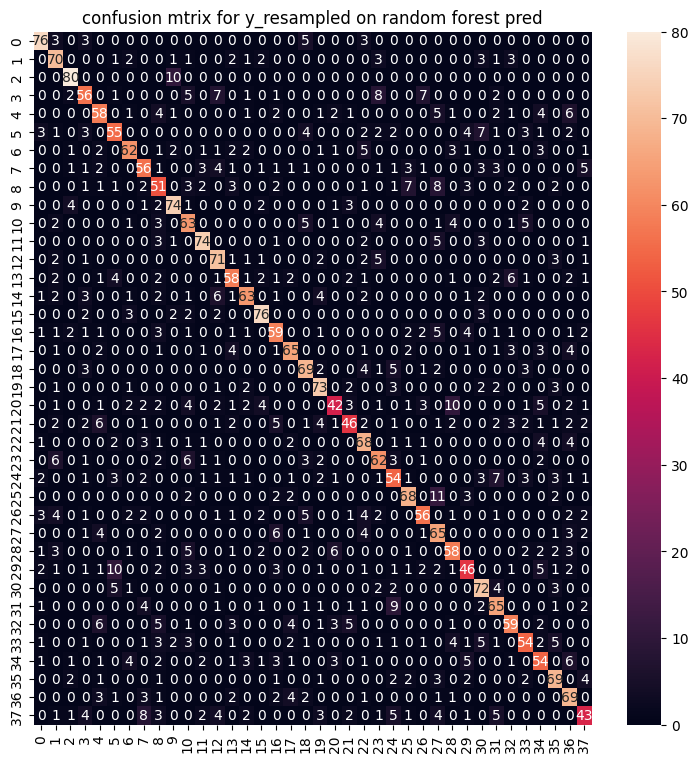

 GaussianNB accuracy:68.98%


In [ ]:
#confusion matrix for random forest classifier
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(x_resampled,y_resampled)
rf_pred = rf_model.predict(x_resampled)

cf_matrix_rf = confusion_matrix(y_resampled,rf_pred)
plt.figure(figsize=(9,9))
plt.title("confusion matrix for y_resampled on random forest pred")
sns.heatmap(cf_matrix_rf,annot=True,fmt="d" )
plt.show()

print(f" GaussianNB accuracy:{accuracy_score(y_resampled,rf_pred)*100:.2f}%")

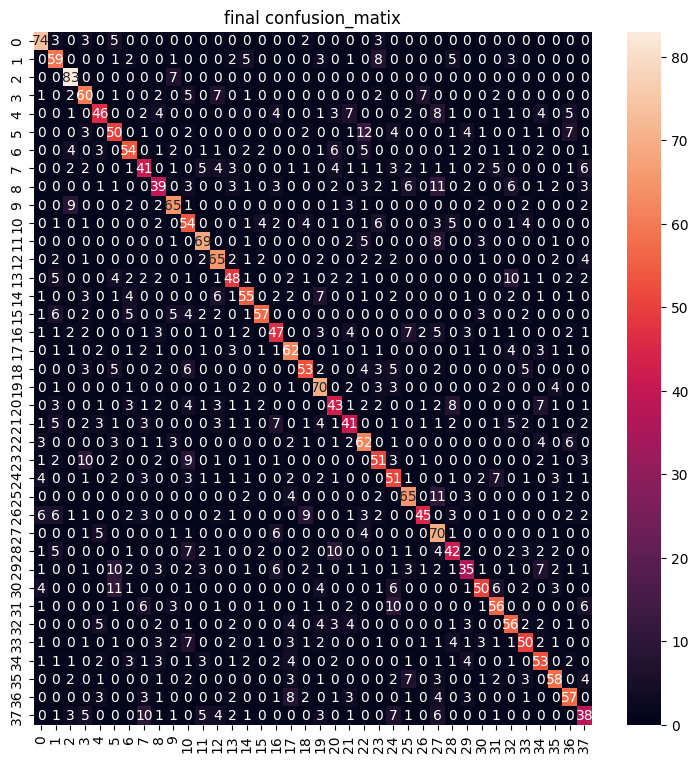

the final accuracy is 60.64%


In [ ]:
from statistics import mode

final_pred = [mode([i,j,k]) for i,j,k in zip(svm_pred,nv_pred,rf_pred)]

final_matrix = confusion_matrix(y_resampled,final_pred)
plt.figure(figsize=(9,9))
plt.title("final confusion_matrix")
sns.heatmap(final_matrix,annot=True,fmt="d")
plt.show()

print(f"the final accuracy is {accuracy_score(y_resampled,final_pred)*100:.2f}%")

In [ ]:
symptoms = x.columns.values
symptoms_index = {symptoms:idx for idx,symptoms in enumerate(symptoms)}
print(symptoms_index)
def predict_disease(input_symptoms):
    input_symptoms = input_symptoms.split(",")
    input_data = [0] * len(symptoms_index)

    for symptom in input_symptoms:
        if symptom in symptoms_index:
            input_data[symptoms_index[symptom]] = 1

    input_df = pd.DataFrame([input_data],columns=symptoms)

    # rf_pred = encoder.classes_[rf_model.predict(input_df)[0]]
    # nv_pred = encoder.classes_[nv_model.predict(input_df)[0]]
    # svm_pred = encoder.classes_[svm_model.predict(input_df)[0]]
    rf_pred = encoder.inverse_transform([rf_model.predict(input_df)[0]])[0]
    svm_pred = encoder.inverse_transform([svm_model.predict(input_df)[0]])[0]
    nv_pred = encoder.inverse_transform([nv_model.predict(input_df)[0]])[0]

    final_pred = mode([rf_pred,nv_pred,svm_pred])

    return{
        "random forest classification": rf_pred,
        "vector metrix classfication": svm_pred,
        "naive bayes classification": nv_pred,
        "final prediction":final_pred
    }

print(predict_disease("skin_rash,fever,headache"))
# print(encoder.classes_[30])


{'fever': 0, 'headache': 1, 'nausea': 2, 'vomiting': 3, 'fatigue': 4, 'joint_pain': 5, 'skin_rash': 6, 'cough': 7, 'weight_loss': 8, 'yellow_eyes': 9}
{'random forest classification': 'Peptic ulcer disease', 'vector metrix classfication': 'Peptic ulcer disease', 'naive bayes classification': 'Impetigo', 'final prediction': 'Peptic ulcer disease'}
Peptic ulcer disease
